# XGBoost - Diabetes Readmission Prediction

Adrian Balingit | CS 549 Final Project (Spring 2026)

Trains an XGBoost classifier to predict 30-day hospital readmission for diabetes patients (UCI Diabetes 130-US Hospitals, 1999-2008).

Steps:
1. Load the shared train/test splits made by `src/data_preparation.py`
2. Baseline XGBoost with default hyperparameters
3. 5-fold cross-validation (default hyperparameters)
4. Hyperparameter tuning with `RandomizedSearchCV`
5. Final model and test-set evaluation
6. Threshold selection on the test PR curve
7. Plots (confusion matrix, ROC curve, feature importance)
8. Summary of timings and metrics

Target: binary `1` if readmitted within 30 days, else `0`. Primary metric: F1. Secondary metric: recall.

In [1]:
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate,
)

RANDOM_STATE = 42
CV_FOLDS = 5
SEARCH_ITERATIONS = 30
RECALL_TARGET = 0.5

## 1. Load splits

Splits come from `src/data_preparation.py`. Train is SMOTE-balanced; test is the original imbalanced distribution (~9% positive).

In [2]:
X_train = pd.read_csv("data/X_train.csv")
X_test  = pd.read_csv("data/X_test.csv")
y_train = pd.read_csv("data/y_train.csv").squeeze("columns")
y_test  = pd.read_csv("data/y_test.csv").squeeze("columns")

print(f"X_train: {X_train.shape}  class balance: {y_train.value_counts().to_dict()}")
print(f"X_test : {X_test.shape}  class balance: {y_test.value_counts().to_dict()}")
print(f"\nPositive rate -> train: {y_train.mean()*100:.1f}%   test: {y_test.mean()*100:.1f}%")

X_train: (101456, 89)  class balance: {0: 50728, 1: 50728}
X_test : (13912, 89)  class balance: {0: 12682, 1: 1230}

Positive rate -> train: 50.0%   test: 8.8%


## 2. Baseline XGBoost (default hyperparameters)

Quick baseline so we have something to compare the tuned model against.

In [3]:
baseline = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

t0 = time.perf_counter()
baseline.fit(X_train, y_train)
baseline_fit_time = time.perf_counter() - t0
print(f"Baseline fit time: {baseline_fit_time:.2f} s")

baseline_proba = baseline.predict_proba(X_test)[:, 1]
baseline_pred  = (baseline_proba >= 0.5).astype(int)
print(f"\nBaseline test results at default 0.5 threshold:")
print(classification_report(y_test, baseline_pred,
                            target_names=["not_readmitted", "readmitted_<30"],
                            zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, baseline_proba):.4f}")
print(f"PR-AUC : {average_precision_score(y_test, baseline_proba):.4f}")

Baseline fit time: 0.53 s

Baseline test results at default 0.5 threshold:
                precision    recall  f1-score   support

not_readmitted       0.91      1.00      0.95     12682
readmitted_<30       0.47      0.02      0.04      1230

      accuracy                           0.91     13912
     macro avg       0.69      0.51      0.50     13912
  weighted avg       0.87      0.91      0.87     13912

ROC-AUC: 0.6355
PR-AUC : 0.1652


## 3. 5-fold cross-validation (default hyperparameters)

Sanity-check on the training set before spending time on tuning.

In [4]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy" : "accuracy",
    "precision": "precision",
    "recall"   : "recall",
    "f1"       : "f1",
    "roc_auc"  : "roc_auc",
}

t0 = time.perf_counter()
cv_results = cross_validate(
    xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    X_train, y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
)
cv_time = time.perf_counter() - t0
print(f"5-fold CV wall time: {cv_time:.2f} s\n")

cv_df = pd.DataFrame({
    "Fold"         : range(1, CV_FOLDS + 1),
    "Accuracy"     : cv_results["test_accuracy"],
    "Precision"    : cv_results["test_precision"],
    "Recall"       : cv_results["test_recall"],
    "F1"           : cv_results["test_f1"],
    "ROC-AUC"      : cv_results["test_roc_auc"],
    "Fit time (s)" : cv_results["fit_time"],
})

mean_row = cv_df.drop(columns="Fold").mean().rename("Mean")
std_row  = cv_df.drop(columns="Fold").std().rename("Std")

display(cv_df.set_index("Fold").style.format("{:.4f}"))
print()
display(pd.DataFrame([mean_row, std_row]).style.format("{:.4f}"))

5-fold CV wall time: 3.06 s



,Accuracy,Precision,Recall,F1,ROC-AUC,Fit time (s)
Fold,,,,,,
1,0.9482,0.9972,0.8990,0.9455,0.9669,1.0852
2,0.9477,0.9966,0.8985,0.9450,0.9665,1.1048
3,0.9462,0.9976,0.8946,0.9433,0.9642,1.0922
4,0.9483,0.9969,0.8993,0.9456,0.9683,1.0928
5,0.9477,0.9973,0.8979,0.9450,0.9678,1.0950


,Accuracy,Precision,Recall,F1,ROC-AUC,Fit time (s)
Mean,0.9476,0.9971,0.8978,0.9449,0.9667,1.0940
Std,0.0008,0.0004,0.0019,0.0009,0.0016,0.0071


## 4. Hyperparameter tuning (RandomizedSearchCV)

Per the project proposal, the search covers `learning_rate`, `max_depth`, `n_estimators`, `subsample`, `min_child_weight`, plus L1 and L2 regularization. Scoring is PR-AUC since the test class is highly imbalanced (PR-AUC handles imbalance better than ROC-AUC).

In [5]:
PARAM_DISTRIBUTIONS = {
    "learning_rate"   : [0.01, 0.05, 0.1, 0.2],
    "max_depth"       : [3, 5, 7, 9],
    "n_estimators"    : [100, 200, 400, 600],
    "subsample"       : [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "min_child_weight": [1, 3, 5],
    "reg_alpha"       : [0.0, 0.1, 1.0],   # L1
    "reg_lambda"      : [0.5, 1.0, 2.0],   # L2
    "gamma"           : [0.0, 0.1, 0.3],
}

search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    param_distributions=PARAM_DISTRIBUTIONS,
    n_iter=SEARCH_ITERATIONS,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

t0 = time.perf_counter()
search.fit(X_train, y_train)
tune_time = time.perf_counter() - t0

best_params = search.best_params_
print(f"\nTuning wall time: {tune_time:.2f} s")
print(f"Best CV PR-AUC : {search.best_score_:.4f}")
print(f"Best params    : {json.dumps(best_params, indent=2)}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Tuning wall time: 53.32 s
Best CV PR-AUC : 0.9796
Best params    : {
  "subsample": 0.7,
  "reg_lambda": 1.0,
  "reg_alpha": 0.0,
  "n_estimators": 400,
  "min_child_weight": 3,
  "max_depth": 9,
  "learning_rate": 0.05,
  "gamma": 0.0,
  "colsample_bytree": 0.7
}


## 5. Final model and test-set evaluation

Refit using the best hyperparameters on the full training set and predict on the held-out test set.

In [6]:
final_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_params,
)

t0 = time.perf_counter()
final_model.fit(X_train, y_train)
final_fit_time = time.perf_counter() - t0

t0 = time.perf_counter()
y_proba = final_model.predict_proba(X_test)[:, 1]
final_infer_time = time.perf_counter() - t0

roc_auc = roc_auc_score(y_test, y_proba)
pr_auc  = average_precision_score(y_test, y_proba)

print(f"Final fit time     : {final_fit_time:.2f} s")
print(f"Final inference    : {final_infer_time*1000:.2f} ms (test set, {len(X_test)} rows)")
print(f"\nROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC : {pr_auc:.4f}")

Final fit time     : 2.33 s
Final inference    : 24.14 ms (test set, 13912 rows)

ROC-AUC: 0.6376
PR-AUC : 0.1684


## 6. Threshold selection (test PR curve)

Pick two operating points:
- F1-optimal threshold (primary metric)
- Recall-target threshold with R >= 0.5 (secondary metric)

In [7]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
p_arr, r_arr = precisions[:-1], recalls[:-1]

# F1-optimal
f1s = 2 * p_arr * r_arr / (p_arr + r_arr + 1e-12)
f1_idx = int(np.argmax(f1s))
f1_threshold = float(thresholds[f1_idx])

# highest threshold (best precision) where recall >= target
feasible = np.where(r_arr >= RECALL_TARGET)[0]
rt_idx = int(feasible[-1]) if len(feasible) else int(np.argmax(r_arr))
rt_threshold = float(thresholds[rt_idx])

print(f"F1-optimal threshold  : {f1_threshold:.4f}")
print(f"  Precision = {p_arr[f1_idx]:.4f}, Recall = {r_arr[f1_idx]:.4f}, F1 = {f1s[f1_idx]:.4f}")
print(f"\nRecall-target threshold (R >= {RECALL_TARGET}): {rt_threshold:.4f}")
print(f"  Precision = {p_arr[rt_idx]:.4f}, Recall = {r_arr[rt_idx]:.4f}")

F1-optimal threshold  : 0.1459
  Precision = 0.1671, Recall = 0.3309, F1 = 0.2221

Recall-target threshold (R >= 0.5): 0.1087
  Precision = 0.1337, Recall = 0.5000


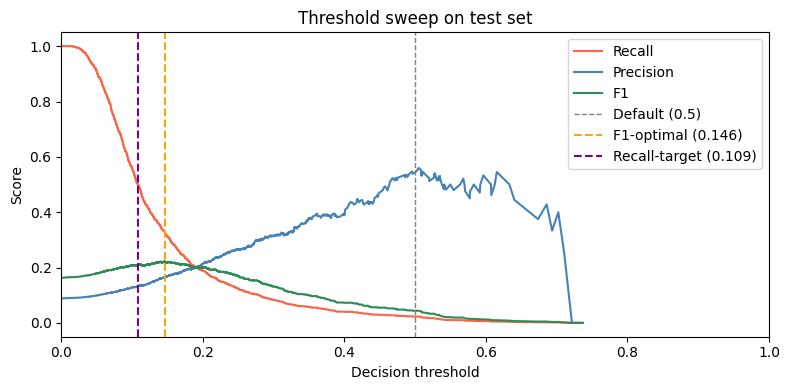

In [8]:
# Threshold sweep plot - shows the precision/recall tradeoff
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, r_arr, label="Recall",    color="tomato")
ax.plot(thresholds, p_arr, label="Precision", color="steelblue")
ax.plot(thresholds, f1s,   label="F1",        color="seagreen")
ax.axvline(0.5,          color="gray",   lw=1,   ls="--", label="Default (0.5)")
ax.axvline(f1_threshold, color="orange", lw=1.5, ls="--", label=f"F1-optimal ({f1_threshold:.3f})")
ax.axvline(rt_threshold, color="purple", lw=1.5, ls="--", label=f"Recall-target ({rt_threshold:.3f})")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold sweep on test set")
ax.set_xlim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

### Performance at each operating point

In [9]:
def report_at(threshold, label):
    y_pred = (y_proba >= threshold).astype(int)
    print(f"\n--- {label} (threshold = {threshold:.4f}) ---")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"F1       : {f1_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"F2       : {fbeta_score(y_test, y_pred, beta=2, zero_division=0):.4f}")
    print(classification_report(y_test, y_pred,
                                target_names=["not_readmitted", "readmitted_<30"],
                                zero_division=0))

report_at(0.5,            "Default 0.5")
report_at(f1_threshold,   "F1-optimal (primary metric)")
report_at(rt_threshold,   f"Recall-target R >= {RECALL_TARGET} (secondary metric)")


--- Default 0.5 (threshold = 0.5000) ---
Accuracy : 0.9119
Precision: 0.5490
Recall   : 0.0228
F1       : 0.0437
F2       : 0.0282
                precision    recall  f1-score   support

not_readmitted       0.91      1.00      0.95     12682
readmitted_<30       0.55      0.02      0.04      1230

      accuracy                           0.91     13912
     macro avg       0.73      0.51      0.50     13912
  weighted avg       0.88      0.91      0.87     13912


--- F1-optimal (primary metric) (threshold = 0.1459) ---
Accuracy : 0.7951
Precision: 0.1671
Recall   : 0.3309
F1       : 0.2221
F2       : 0.2767
                precision    recall  f1-score   support

not_readmitted       0.93      0.84      0.88     12682
readmitted_<30       0.17      0.33      0.22      1230

      accuracy                           0.80     13912
     macro avg       0.55      0.59      0.55     13912
  weighted avg       0.86      0.80      0.82     13912


--- Recall-target R >= 0.5 (secondary met

## 7. Plots

Confusion matrix at the F1-optimal threshold, ROC curve, and top feature importances.

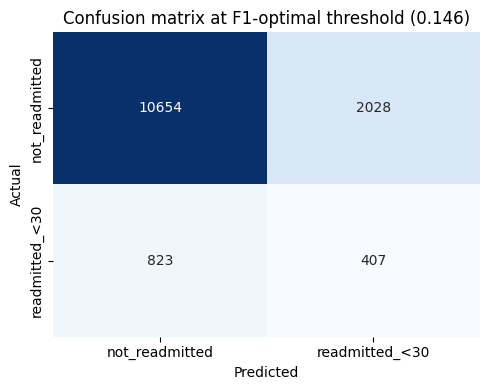

In [10]:
y_pred_f1 = (y_proba >= f1_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_f1)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["not_readmitted", "readmitted_<30"],
    yticklabels=["not_readmitted", "readmitted_<30"],
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix at F1-optimal threshold ({f1_threshold:.3f})")
plt.tight_layout()
plt.show()

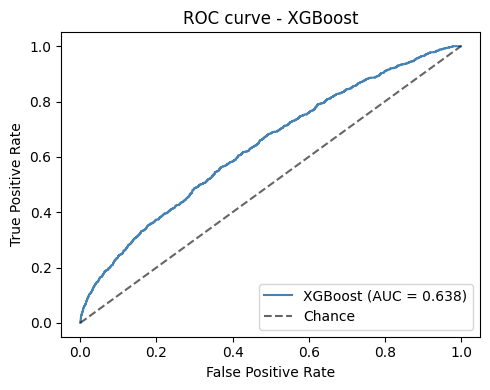

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.3f})", color="steelblue")
ax.plot([0, 1], [0, 1], "k--", alpha=0.6, label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curve - XGBoost")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

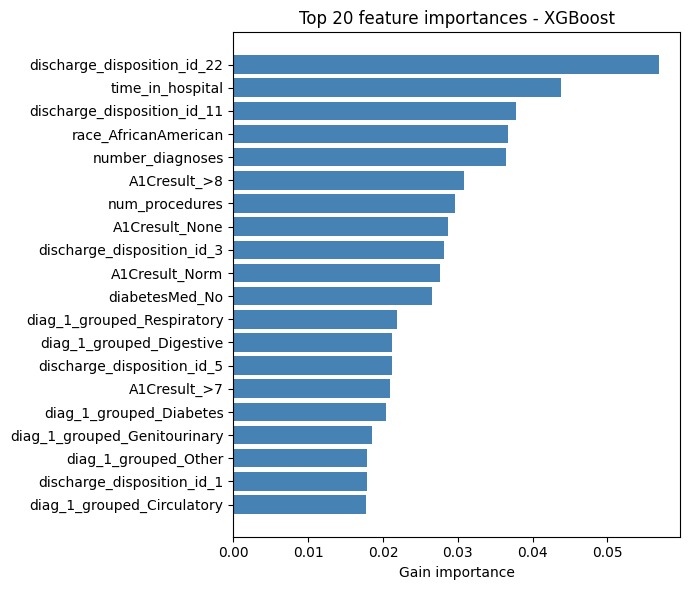

In [12]:
TOP_N = 20
importances = final_model.feature_importances_
order = np.argsort(importances)[::-1][:TOP_N]
top_features = [X_train.columns[i] for i in order]
top_values   = importances[order]

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(range(TOP_N), top_values[::-1], color="steelblue")
ax.set_yticks(range(TOP_N))
ax.set_yticklabels(top_features[::-1])
ax.set_xlabel("Gain importance")
ax.set_title(f"Top {TOP_N} feature importances - XGBoost")
plt.tight_layout()
plt.show()

## 8. Summary

Timing breakdown and metrics across operating points - this is the table for the comparative-analysis section of the report.

In [13]:
print("=" * 50)
print("XGBoost - Final Summary")
print("=" * 50)

print("\n[Timings]")
print(f"  Baseline fit time     : {baseline_fit_time:.2f} s")
print(f"  5-fold CV wall time   : {cv_time:.2f} s")
print(f"  Hyperparameter tuning : {tune_time:.2f} s")
print(f"  Final fit time        : {final_fit_time:.2f} s")
print(f"  Final inference time  : {final_infer_time*1000:.2f} ms")

print("\n[Threshold-independent metrics on test set]")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  PR-AUC : {pr_auc:.4f}")

y_pred_default = (y_proba >= 0.5).astype(int)
y_pred_f1      = (y_proba >= f1_threshold).astype(int)
y_pred_rt      = (y_proba >= rt_threshold).astype(int)
preds = [y_pred_default, y_pred_f1, y_pred_rt]

summary_df = pd.DataFrame({
    "Threshold": [0.5, f1_threshold, rt_threshold],
    "Precision": [precision_score(y_test, p, zero_division=0) for p in preds],
    "Recall"   : [recall_score(y_test, p, zero_division=0) for p in preds],
    "F1"       : [f1_score(y_test, p, zero_division=0) for p in preds],
    "F2"       : [fbeta_score(y_test, p, beta=2, zero_division=0) for p in preds],
}, index=["Default 0.5", "F1-optimal (primary)", f"Recall >= {RECALL_TARGET} (secondary)"])

print("\n[Metrics at each operating point]")
display(summary_df.style.format("{:.4f}"))

XGBoost - Final Summary

[Timings]
  Baseline fit time     : 0.53 s
  5-fold CV wall time   : 3.06 s
  Hyperparameter tuning : 53.32 s
  Final fit time        : 2.33 s
  Final inference time  : 24.14 ms

[Threshold-independent metrics on test set]
  ROC-AUC: 0.6376
  PR-AUC : 0.1684

[Metrics at each operating point]


,Threshold,Precision,Recall,F1,F2
Default 0.5,0.5000,0.5490,0.0228,0.0437,0.0282
F1-optimal (primary),0.1459,0.1671,0.3309,0.2221,0.2767
Recall >= 0.5 (secondary),0.1087,0.1337,0.5000,0.2110,0.3230
